This notebook checks some gene-disease associations (GDA) characteristics

In [1]:
import requests
import json
import os
import pandas as pd
import urllib.request, urllib.error, urllib.parse
import pickle as pk
import networkx as nx
import random as rd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from collections import Counter
import seaborn as sns

In [2]:
#Let's import the unified gene annotations

with open('output/allsources_icd_gene_dict_unified_v2026_official.pickle', 'rb') as handle:
    allsources_icd_gene_dict_unified = pk.load(handle)

#Let's import the unified gene annotations lcc z-score
with open('output/allsources_icd_gene_dict_unified_lcczscore_v2026_official.pickle', 'rb') as handle:
    allsources_icd_gene_dict_unified_lcczscore = pk.load(handle)



In [21]:
icd_name = []
icd_length = []
z_score_list = []
for icd,genelist in allsources_icd_gene_dict_unified.items():
    icd_name.append(icd)
    icd_length.append(len(genelist))
    try:
        z_score_list.append(allsources_icd_gene_dict_unified_lcczscore[icd])
    except:
        z_score_list.append("NA")

icd_characteristics_df = pd.DataFrame(list(zip(icd_name, icd_length,z_score_list)), columns =['icd', 'genelist_length','z_score'])
icd_characteristics_df.to_csv("output/icd_characteristics_df_v2026_official.csv",index=False)

In [4]:
#Let's import the results
with open('output/ncbi_disease_icd_gene_dict_v2026_official.pickle', 'rb') as handle:
    ncbi_disease_icd_gene_dict = pk.load(handle)

with open('output/ncbi_disease_gene_clinvar_icd_dict_v2026_official.pickle', 'rb') as handle:
    ncbi_disease_gene_clinvar_icd_dict = pk.load(handle)

with open('output/disease_enhancer_genes_icd_dict_v2026_official.pickle', 'rb') as handle:
    disease_enhancer_genes_icd_dict = pk.load(handle)

with open('output/diseases_icd_id_genes_dict_v2026_official.pickle', 'rb') as handle:
    diseases_icd_id_genes_dict = pk.load(handle)

with open('output/omim_icd_gene_dict_v2026_official.pickle', 'rb') as handle:
    omim_icd_gene_dict = pk.load(handle)

with open('output/gwas_icd_gene_dict_v2026_official.pickle', 'rb') as handle:
    gwas_icd_gene_dict = pk.load(handle)

with open('output/OrphaData_icd_gene_dict_v2026_official.pickle', 'rb') as handle:
    OrphaData_icd_gene_dict = pk.load(handle)

with open('output/disgenet_icd10_genes_dict_unified_genelist_v2026.pickle', 'rb') as handle:
    disgenet_icd10_genes_dict_unified_genelist = pk.load(handle)

with open('output/opentargets_icd10_genes_dict_unified_genelist_2026_official.pickle', 'rb') as handle:
    opentargets_icd_unified_genelist = pk.load(handle)



In [5]:
sources_dict = {}

#sources_dict['NCBI_genetests'] = ncbi_disease_icd_gene_dict  #we need to remove this source because it is too noisy
sources_dict['NCBI_ClinVar'] = ncbi_disease_gene_clinvar_icd_dict
sources_dict['Disease_ehancer'] = disease_enhancer_genes_icd_dict
sources_dict['DISEASES'] = diseases_icd_id_genes_dict
sources_dict['OMIM'] = omim_icd_gene_dict
sources_dict['GWAS'] = gwas_icd_gene_dict
sources_dict['Orphanet'] = OrphaData_icd_gene_dict
sources_dict['DisgeNET'] = disgenet_icd10_genes_dict_unified_genelist
sources_dict['OpenTargets'] = opentargets_icd_unified_genelist

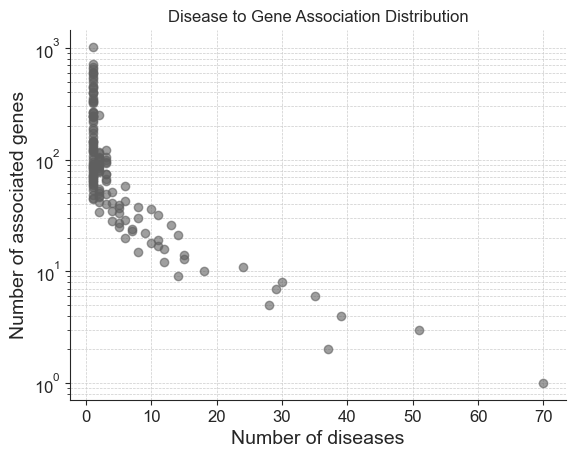

In [24]:
import matplotlib.pyplot as plt
from collections import Counter

# Step 1: Calculate the number of genes for each disease.
# This gives us the distribution of genes for each disease.
disease_gene_counts = [len(genelist) for genelist in allsources_icd_gene_dict_unified.values()]

# Step 2: Count how many diseases have the same number of associated genes.
gene_count_distribution = Counter(disease_gene_counts)

# Step 3: Prepare data for the plot.
# x-axis will be the number of diseases, y-axis will be the count of related genes.
x_values = list(gene_count_distribution.values())  # Number of diseases
y_values = list(gene_count_distribution.keys())    # Number of genes associated with those diseases

# Sorting data for better visualization
sorted_indices = sorted(range(len(x_values)), key=lambda k: x_values[k])
x_values = [x_values[i] for i in sorted_indices]
y_values = [y_values[i] for i in sorted_indices]

# Step 4: Plotting
fig, ax = plt.subplots()
ax.scatter(x_values, y_values, c='#5F5F5F', alpha=0.6)

#plt.xscale('log')  # Log scale if data distribution is wide
plt.yscale('log')
plt.xlabel('Number of diseases', fontsize=14)
plt.ylabel('Number of associated genes', fontsize=14)
plt.title('Disease to Gene Association Distribution')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Optionally enhance readability with grid lines
ax.grid(True, which="both", ls="--", linewidth=0.5)

# Simplify plot
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()
plt.close()

In [25]:
#Let's plot the disease-geneset size distribution

tot_genelist_len=[]
for dis,genelist in allsources_icd_gene_dict_unified.items():
    tot_genelist_len.append(len(genelist))

tot_genelist_len_counter = Counter(tot_genelist_len)
tot_genelist_len_counter_x = list(tot_genelist_len_counter.keys())
tot_genelist_len_counter_y = list(tot_genelist_len_counter.values())

/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_743/955755117.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


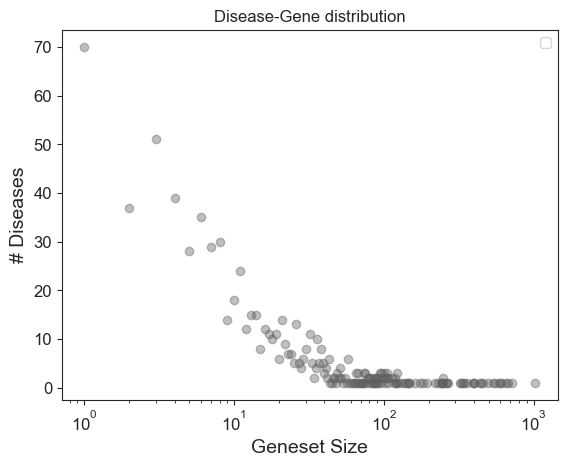

In [26]:
#Here, we compare the distribution of the total (raw) exposures/perturbed genes and the backboning

plt.scatter(tot_genelist_len_counter_x, tot_genelist_len_counter_y, c='#5F5F5F', alpha=0.4)
plt.xscale('log')
#plt.yscale('log')
plt.xlabel('Geneset Size', fontsize=14)
plt.ylabel('# Diseases', fontsize=14)
plt.xticks(fontsize=12, rotation=0)
plt.yticks(fontsize=12, rotation=0)
plt.title('Disease-Gene distribution')
plt.legend()
plt.savefig('Figures/Fig1B_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")  #This is now Fig1C
plt.show()

In [27]:
sum(tot_genelist_len_counter_y)

766

In [28]:
np.median(tot_genelist_len)

12.0

In [ ]:

# Sort the dictionary based on the length of the sets in descending order
sorted_allsources_icd_gene_dict_unified = sorted(allsources_icd_gene_dict_unified.items(), key=lambda item: len(item[1]), reverse=True)

# Extract the top 10 keys
top_10_keys = [key for key, value in sorted_allsources_icd_gene_dict_unified[:10]]

In [30]:
top_10_keys

['F20', 'J45', 'L40', 'H52', 'G35', 'H40', 'M10', 'M32', 'I51', 'I50']

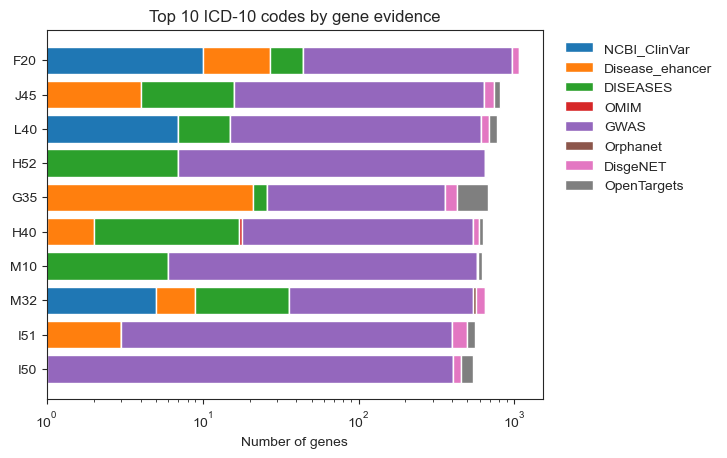

In [31]:

# keep your ICD ordering
y_pos = np.arange(len(top_10_keys))

# get lengths per source for each ICD
source_lengths = {
    src: [len(sources_dict[src].get(dis, [])) for dis in top_10_keys]
    for src in sources_dict
}

fig, ax = plt.subplots()

bottom = np.zeros(len(top_10_keys))

for src, values in source_lengths.items():
    ax.barh(y_pos, values, left=bottom, label=src)
    bottom += np.array(values)

ax.set_yticks(y_pos, labels=top_10_keys)
ax.invert_yaxis()
ax.set_xscale('log')
ax.set_xlabel('Number of genes')
ax.set_title('Top 10 ICD-10 codes by gene evidence')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

plt.savefig('Figures/SF1D_TopICD10codes_stacked_v2026_official.pdf', dpi=300, bbox_inches="tight")
plt.savefig('Figures/SF1D_TopICD10codes_stacked_v2026_official.png', dpi=300, bbox_inches="tight")
plt.show()

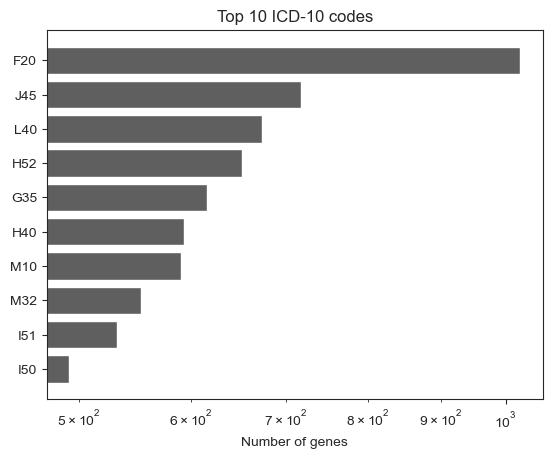

In [32]:
genelist_len = [len(allsources_icd_gene_dict_unified[dis]) for dis in top_10_keys] 

fig, ax = plt.subplots()

y_pos = np.arange(len(top_10_keys))

ax.barh(y_pos, genelist_len, align='center', color='#5F5F5F')
ax.set_yticks(y_pos, labels=top_10_keys)
ax.invert_yaxis()  # labels read top-to-bottom
ax.set_xscale('log')
ax.set_xlabel('Number of genes')
ax.set_title('Top 10 ICD-10 codes')

plt.savefig('Figures/SF1D_TopICD10codes_official.pdf',format='pdf',dpi=300, bbox_inches = "tight") 
plt.savefig('Figures/SF1D_TopICD10codes_official.png',format='pdf',dpi=300, bbox_inches = "tight") 
plt.show()



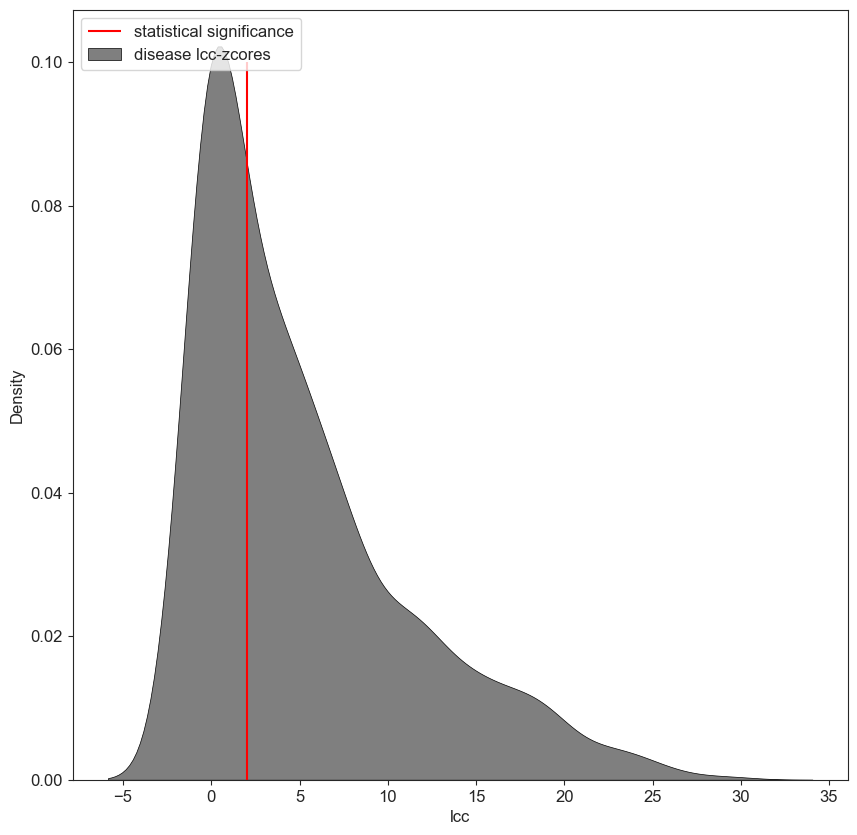

In [33]:
#Let's plot the distribution of all lcc z-scores

lcc_zscores = [i for i in allsources_icd_gene_dict_unified_lcczscore.values() if str(i)!='nan']
# plot distributions for non-sampled case
sns.set_style('white')
sns.set_style("ticks", {"xtick.major.size": 15, "ytick.major.size": 15})
plt.figure(figsize=(10,10))
plt.vlines(2,ymin=0,ymax=0.1,color='r',label='statistical significance')
sns.kdeplot(lcc_zscores,color='k',lw=.5,alpha=.5,fill=True,label='disease lcc-zcores')
plt.legend(loc='upper left',fontsize=12)
plt.ylabel('Density',fontsize=12)
plt.xlabel('lcc',fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig('Figures/Fig1C_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")


In [3]:
# Append to your existing SourceData Excel
lcc_zscores = [i for i in allsources_icd_gene_dict_unified_lcczscore.values() if str(i)!='nan']
source_df = pd.DataFrame({
    "lcc_zscore": lcc_zscores
})

excel_path = "output/SourceData.xlsx"

with pd.ExcelWriter(
        excel_path,
        engine="openpyxl",
        mode="a",
        if_sheet_exists="replace"
    ) as writer:
    source_df.to_excel(
        writer,
        sheet_name="Fig1F",
        index=False
    )

In [34]:
len([i for i in lcc_zscores if i>2])

374

In [35]:
max(lcc_zscores)

29.118017789164004

In [36]:
for k,v in allsources_icd_gene_dict_unified_lcczscore.items():
    try:
        if v>25:
            print(k,v)
    except:
        pass

D05 26.140010219104457
D74 25.460376455008856
E71 29.118017789164004
